# Contextual embeddings: the same word, measured as different vectors

*Companion notebook to the [Contextual Embeddings (ELMo · BERT)](../06-Contextual-Embeddings-ELMo-BERT.md) concept page.*

Read these two sentences: *"I sat on the river **bank**"* and *"I deposited cash at the **bank**."* Your brain
produced a different meaning for **bank** each time, from context. **word2vec / GloVe cannot** — they store
**one** frozen vector per word string, so both senses collapse to the same point. Contextual models fix this:
they recompute a token's vector **from the whole sentence**, so the same word gets **different** vectors in
different contexts.

This notebook *measures* that, end to end, with **one idea per cell**:

1. load a contextual backend (real **BERT-base** when reachable; a deterministic **synthetic** model offline);
2. the same word, two senses → two different vectors (low cosine), same sense → close (high cosine);
3. at **layer 0** the two senses are **identical** — contextualization is built **by depth**;
4. the **masked-LM** objective in action — mask a token, read BERT's top predictions;
5. the static-vs-contextual geometry as a 2-D PCA.

Every cell **asserts its qualitative point first**, then prints — so a broken backend fails loudly rather than
printing a wrong number. The math/figures are imported from `contextual_embeddings.py` (the single source of
truth shared by the page and `make_figures_06.py`), so nothing here can drift from the page.

> **Always runs, no network needed.** If BERT can't be downloaded (offline/firewall), every cell falls back to
> the seeded synthetic model and still demonstrates the *shape* of the result — clearly labelled `synthetic`.


## Step 1 — load a contextual backend (device-agnostic, reproducible)

We pick the device at runtime (CUDA → MPS → CPU so it runs anywhere) but **pin execution to CPU**: the measured
vectors must be bit-for-bit reproducible, and GPU/MPS reductions are not guaranteed identical. `load_contextual_model()`
returns real **BERT-base** if the weights are reachable, else the seeded synthetic fallback — and tells us which ran.


In [1]:
import numpy as np
import torch

import contextual_embeddings as ce

print(ce.device_report())                      # honest: detected accelerator, pinned to CPU
print("torch:", torch.__version__, " numpy:", np.__version__)

backend = ce.load_contextual_model()           # real BERT if reachable, else synthetic fallback
tag = "real" if backend.is_real else "synthetic (fallback)"
print(f"backend: {backend.name} ({tag})")

# The page's numbers below are reproducible on EITHER backend (synthetic preserves the qualitative shape).
assert backend.is_real or backend.synthetic is not None, "a backend must always load"


device: cpu (detected mps; pinned to CPU for reproducibility)
torch: 2.12.0  numpy: 2.4.6


backend: bert-base-uncased (real)


## Step 2 — the same word, two senses → two different vectors

We read the contextual vector for **`bank`** (last layer) from four sentences — one riverside, three financial —
and compare with cosine similarity. The contract the page asserts, checked *before* we print:

- **different sense** (river vs money, river vs loan) → **low** cosine;
- **same sense** (money vs a second money sentence) → **high** cosine.

The same string lands in two different regions of space, decided by context.


In [2]:
cos = ce.sense_cosines(backend)

# Assert the qualitative contract FIRST: same-sense must beat both cross-sense pairs.
assert cos["money_money2"] > cos["river_money"], "same-sense should beat cross-sense"
assert cos["money_money2"] > cos["river_loan"],  "same-sense should beat cross-sense"

print(f"cos('bank' river , 'bank' money ) = {cos['river_money']:.3f}   different sense -> far")
print(f"cos('bank' river , 'bank' loan  ) = {cos['river_loan']:.3f}   different sense -> far")
print(f"cos('bank' money , 'bank' money2) = {cos['money_money2']:.3f}   same sense      -> close")


cos('bank' river , 'bank' money ) = 0.480   different sense -> far
cos('bank' river , 'bank' loan  ) = 0.430   different sense -> far
cos('bank' money , 'bank' money2) = 0.810   same sense      -> close


## Step 3 — contextualization is built **by depth** (the layer-0 = static clincher)

The decisive experiment. We compare river-`bank` vs money-`bank` at **every** layer. At **layer 0** — the input
embedding, *before any transformer block* — the two vectors are **identical** (cosine ≈ 1.000), because layer 0 is
essentially a static lookup. Through the stack, self-attention mixes context in and the two senses **pull apart**.

So "contextual" is not present at the input — it is **built by the attention layers**. We assert layer-0 is static
and that depth strictly reduces the similarity, then print the curve.


In [3]:
probe = ce.layer_probe(backend, ce.RIVER, ce.MONEY)

# Assert: layer 0 is static (~1.0), and SOME deeper layer pulls the senses apart.
assert probe.layer0_cosine > 0.99, "layer 0 (input embedding) should be ~static/identical"
assert min(probe.per_layer_cosine) < probe.layer0_cosine, "depth must pull the senses apart"

min_layer = int(np.argmin(probe.per_layer_cosine))
print("layer | cosine(river-bank, money-bank)")
for layer, c in enumerate(probe.per_layer_cosine):
    mark = "  <- static input" if layer == 0 else ("  <- most disambiguated" if layer == min_layer else "")
    print(f"  {layer:>2}  | {c:.3f}{mark}")


layer | cosine(river-bank, money-bank)
   0  | 1.000  <- static input
   1  | 0.728
   2  | 0.635
   3  | 0.557
   4  | 0.564
   5  | 0.540
   6  | 0.535
   7  | 0.467
   8  | 0.446
   9  | 0.411  <- most disambiguated
  10  | 0.422
  11  | 0.472
  12  | 0.480


**Read the curve top to bottom.** It starts at **1.000** (static input), falls through the stack to its minimum
in the **upper-middle** layers (where word sense is most resolved), then **ticks back up** slightly at the very top —
because the final layers re-specialize toward the pretraining (masked-LM) objective. That last fact is exactly *why*
practitioners don't just grab the last layer when extracting embeddings — the most transferable representations sit
a little below the top.


## Step 4 — the masked-LM objective in action

BERT was trained to **fill in blanks**: hide ~15% of tokens and predict them from **both-sided** context. We feed a
sentence with one `[MASK]` and read the top predictions. Because the encoder is bidirectional, *"deposited cash at
the [MASK] downtown"* gives the model both the left (*deposited cash*) and right (*downtown*) context to recover
**`bank`**. We assert the expected word is in the top-k, then print the distribution.


In [4]:
prompt = "I deposited cash at the [MASK] downtown."
preds = ce.top_fill(backend, prompt, k=5)
words = [w for w, _ in preds]

# Assert the model recovers a financial-place word from both-sided context.
assert any(w in {"bank", "atm", "store", "office"} for w in words), f"unexpected fills: {words}"

print(f"prompt: {prompt!r}")
for word, prob in preds:
    print(f"  {word:>8s}  {prob:.3f}")


prompt: 'I deposited cash at the [MASK] downtown.'
      bank  0.428
       atm  0.186
     hotel  0.055
     store  0.025
    office  0.019


In [5]:
# Two more prompts: a factual one (both-sided context pins a single answer) and the river sense of 'bank'.
for prompt in ("The capital of France is [MASK].", "I sat on the river [MASK] watching the water."):
    preds = ce.top_fill(backend, prompt, k=3)
    print(f"{prompt!r:52s} -> {preds}")


'The capital of France is [MASK].'                   -> [('paris', 0.417), ('lille', 0.071), ('lyon', 0.063)]
'I sat on the river [MASK] watching the water.'      -> [('##bank', 0.398), ('bank', 0.364), (',', 0.17)]


Same architecture, two jobs: the financial sentence fills with **bank** and the factual one with **paris** — both
inferred from *surrounding* tokens, which is precisely the objective that makes BERT's hidden states context-aware
everywhere. (On the synthetic backend these are fixed, plausible stand-ins, clearly labelled — they show the *shape*
of the output offline.)


## Step 5 — see the geometry: static vs contextual in 2-D

Finally, the picture. We pull `bank` from **8 sentences** (4 river, 4 money) through the backend, project the
last-layer vectors to 2-D with PCA, and overlay the **single static vector** (the centroid — one fixed point a
word2vec/GloVe lookup would give). The contextual vectors split into a **river cluster** and a **money cluster**;
the static point cannot be in two places at once. We assert the clusters are actually separated, then plot.


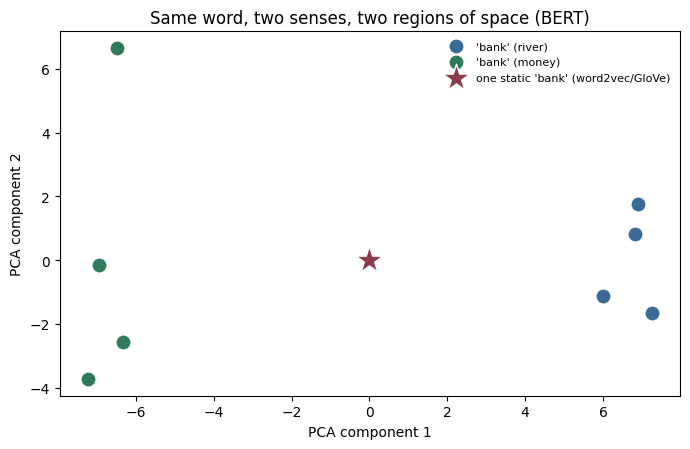

In [6]:
import matplotlib.pyplot as plt

matrix, senses, _ = ce.collect_sense_vectors(backend)
coords = ce.pca_2d(matrix)
static_pt = ce.static_baseline_point(matrix)

river_idx = [i for i, s in enumerate(senses) if s == "river"]
money_idx = [i for i, s in enumerate(senses) if s == "money"]

# Assert the two clusters' centroids are meaningfully apart in the 2-D projection.
river_c = coords[river_idx].mean(axis=0)
money_c = coords[money_idx].mean(axis=0)
assert np.linalg.norm(river_c - money_c) > 1e-3, "river and money 'bank' should separate"

plt.figure(figsize=(7, 4.6))
plt.scatter(coords[river_idx, 0], coords[river_idx, 1], s=120, color="#3A6B96", edgecolor="white", label="'bank' (river)")
plt.scatter(coords[money_idx, 0], coords[money_idx, 1], s=120, color="#2E7A5A", edgecolor="white", label="'bank' (money)")
plt.scatter([static_pt[0]], [static_pt[1]], marker="*", s=420, color="#8B3B4A", edgecolor="white",
            label="one static 'bank' (word2vec/GloVe)")
plt.xlabel("PCA component 1"); plt.ylabel("PCA component 2")
plt.title(f"Same word, two senses, two regions of space ({'BERT' if backend.is_real else 'synthetic'})")
plt.legend(frameon=False, fontsize=8); plt.tight_layout()
plt.show()


## Recap

- **Static** embeddings store **one vector per word type** → polysemy collapses (`bank` is one point forever).
- **Contextual** embeddings recompute a token's vector **from the whole sentence** → the same word gets different
  vectors by context (measured: `bank` river-vs-money ≈ **0.48**, same-sense ≈ **0.81**).
- The clincher: at **layer 0** the two senses are **identical (1.000)** — **contextualization is built by depth**,
  by the transformer stack, not present at the input.
- BERT's **masked-LM** objective (predict hidden tokens from both-sided context) is what makes those hidden states
  good general-purpose contextual features — and dodges the "see your own answer" leak a bidirectional next-token
  model would suffer.

For the full story — ELMo's biLM and per-task layer weighting, the 80/10/10 masking trick derived, NSP and why
RoBERTa dropped it, the BERT family (RoBERTa / ALBERT / DeBERTa / ELECTRA / DistilBERT), extraction pitfalls, the
SBERT `[CLS]` trap, and BERT-vs-GPT — see the **[concept page](../06-Contextual-Embeddings-ELMo-BERT.md)**.

*Regenerate the page's figures from these same functions with* `python make_figures_06.py`.
